# Error types on the 0-facts

What students actually answer on `0×n` and `n×0`, by classroom course age. Source: A998 fluency test,
same population and filters as the RT notebook (`DECISIONS.txt` #1–#11). Query: `queries/answers_by_fact_age.sql`.

In [23]:
import re, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from cached_query import cached_query

from plot_style import C_DIR, C_OTHER, C_TYPES, C_ZERO, FONT_BIG, FONT_MED, paint_it_black, set_style

SQL = ROOT / "queries/answers_by_fact_age.sql"
PLOTS = ROOT / "analysis" / "plots"; PLOTS.mkdir(exist_ok=True)
MIN_N = 30          # DECISIONS #11, applied per fact x age cell
set_style()

In [24]:
ERROR_TYPES = ["= n (additive)", "= 1", "Other digit", "≥ 10"]

def load_answers(year):
    sql = re.sub(r"'[A-Z_0-9-]+'(\s+-- \{YEAR\})", f"'{year}'\\1", SQL.read_text(encoding="utf-8"))
    df = cached_query(SQL, cache_dir=ROOT / "cache", sql_text=sql)
    df = df[df.groupby(["course_age", "operation"]).n_responses.transform("sum").ge(MIN_N)].copy()
    a, b, ans = df.left_factor, df.right_factor, df.answer
    df["has_zero"] = a.eq(0) | b.eq(0)
    df["correct_answer"] = a * b
    df["n"] = np.where(a.eq(0), b, a)                      # non-zero operand of a 0-fact
    df["direction"] = np.where(a.eq(0), "0xn", "nx0")
    df["is_error"] = df.statement_result.ne("Correct")
    df["answered"] = df.answer_kind.eq("int")
    df["error_type"] = np.select(
        [~df.answered, ans.eq(a + b), ans.eq(1), ans.between(2, 9)],
        ["No answer", "= n (additive)", "= 1", "Other digit"], default="≥ 10")
    return df

def save(fig, stem):
    fig.savefig(PLOTS / f"{stem}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(PLOTS / f"{stem}.png", dpi=300, bbox_inches="tight")

## Coverage

`0×0` is kept apart everywhere below: its correct answer *is* 0, so `a+b = n` is not an error for it.
Age 8 is dropped from the 0-fact panels — the test administers no 0-facts at that age (DECISIONS #12).

In [25]:
df = load_answers("ES_2025")

def coverage(d):
    g = d.groupby("course_age")
    out = pd.DataFrame({"facts": g.operation.nunique(),
                        "responses": g.n_responses.sum(),
                        "errors": d[d.is_error].groupby("course_age").n_responses.sum(),
                        "help": d[d.statement_result.eq("Help")].groupby("course_age").n_responses.sum(),
                        "no_answer": d[~d.answered].groupby("course_age").n_responses.sum()}).fillna(0).astype(int)
    return out.assign(error_rate=(100 * out.errors / out.responses).round(1))

zero = df[df.has_zero & df.n.gt(0)]
display(coverage(zero).rename_axis("0-facts (0×n, n×0)"))
display(coverage(df[~df.has_zero]).rename_axis("Other facts"))
display(coverage(df[df.operation.eq("0×0")]).rename_axis("0×0"))

,facts,responses,errors,help,no_answer,error_rate
"0-facts (0×n, n×0)",,,,,,
9,18,34498,7021,14,30,20.4
10,18,131773,17227,62,95,13.1
11,18,148666,16067,42,62,10.8
12,18,69022,6378,26,35,9.2
13,18,70961,5376,17,19,7.6
14,18,36474,1935,5,8,5.3
15,18,10457,322,0,0,3.1


,facts,responses,errors,help,no_answer,error_rate
Other facts,,,,,,
8,72,1004633,382133,12264,13147,38.0
9,81,1044614,214304,5454,6039,20.5
10,81,599931,102613,2048,2345,17.1
11,81,674009,88944,1558,1798,13.2
12,81,306175,35233,478,559,11.5
13,81,313677,28311,199,230,9.0
14,81,161237,13290,34,43,8.2
15,81,46285,3664,7,10,7.9


,facts,responses,errors,help,no_answer,error_rate
0×0,,,,,,
9,1,1897,79,0,1,4.2
10,1,7403,243,3,3,3.3
11,1,8269,172,3,4,2.1
12,1,3839,68,1,2,1.8
13,1,3982,48,0,1,1.2
14,1,2053,15,0,0,0.7
15,1,621,6,0,0,1.0


## Response histogram

The answer given when the response is wrong, as a share of the answered errors of its group
(`Help` / no answer excluded). The two groups do not share an answer space: on a 0-fact a wrong
answer is always a single digit, on the rest it is two-digit about 40% of the time.

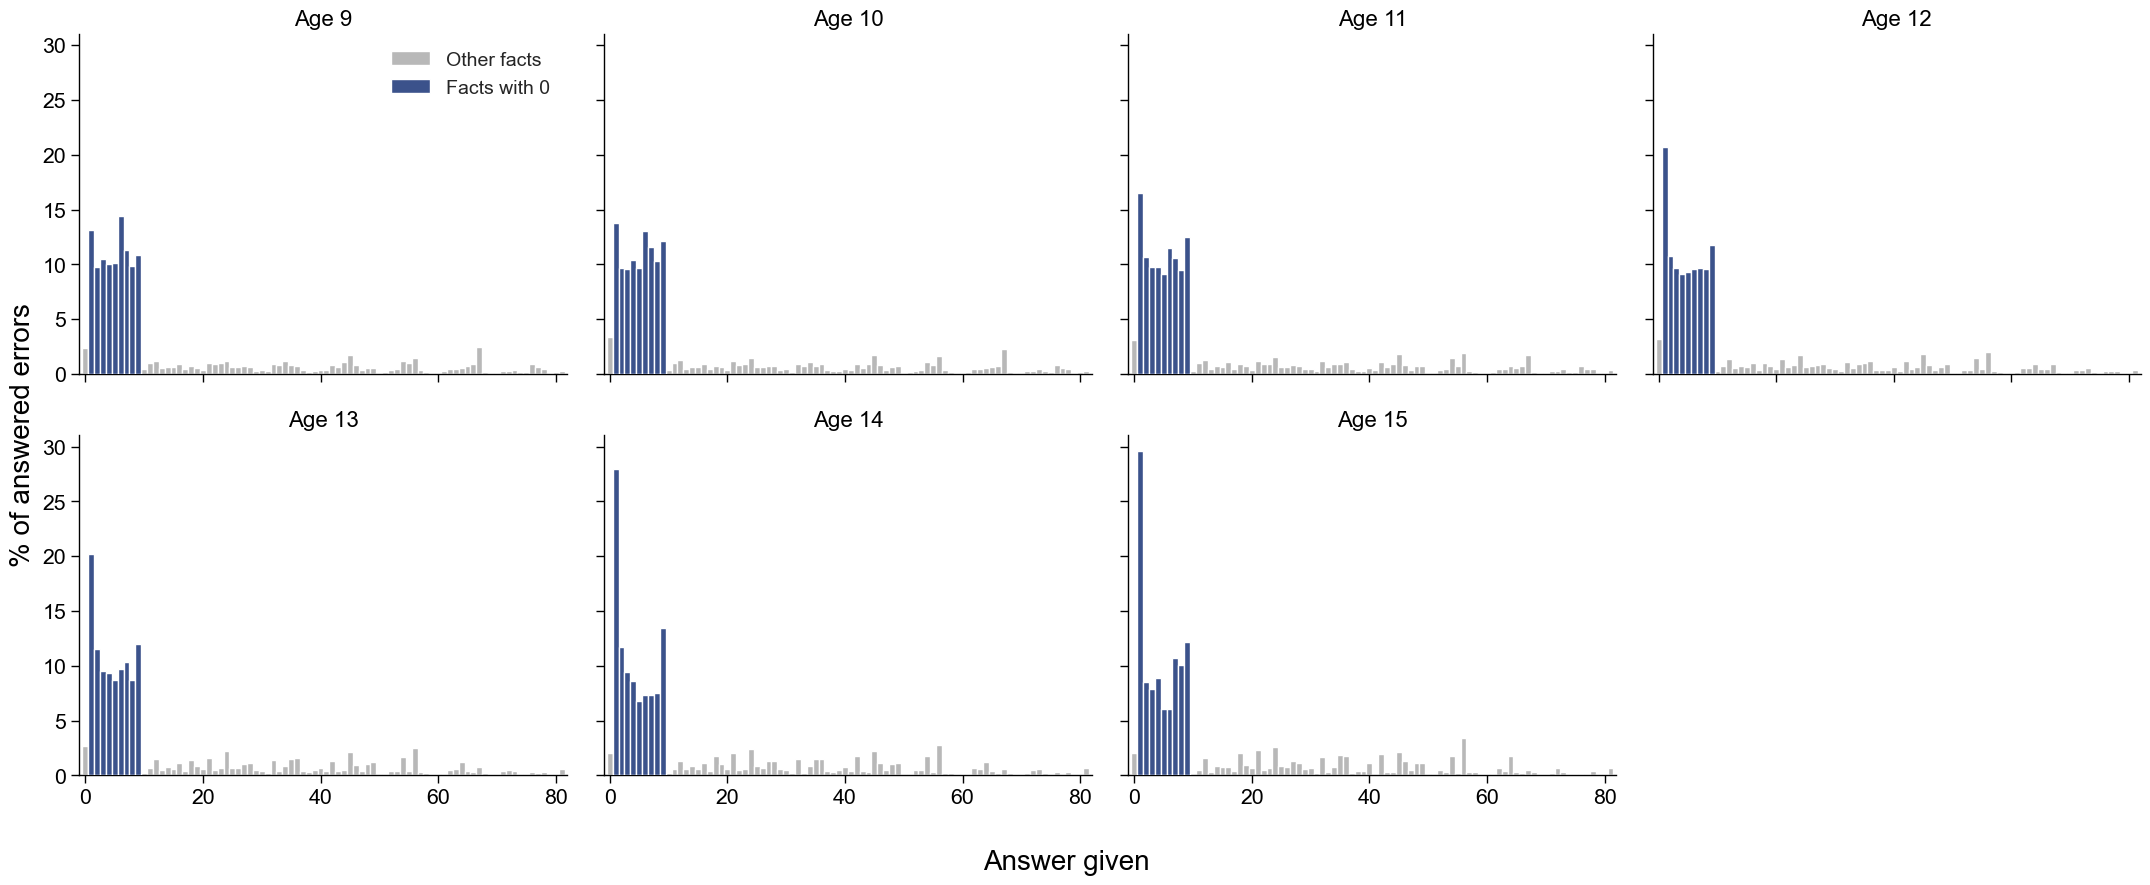

In [26]:
def answer_hist(d, stem):
    ages = sorted(d[d.has_zero].course_age.unique())
    ncols = min(4, len(ages)); nrows = -(-len(ages) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows),
                             sharex=True, sharey=True, squeeze=False)
    for ax, age in zip(axes.flat, ages):
        p = d[d.course_age.eq(age) & d.answered & d.is_error]
        for zero_group, color, label in [(False, C_OTHER, "Other facts"), (True, C_ZERO, "Facts with 0")]:
            s = p[p.has_zero.eq(zero_group)].groupby("answer").n_responses.sum().reindex(range(82), fill_value=0)
            ax.bar(s.index, 100 * s / s.sum(), width=1.0, color=color, label=label, zorder=2 + zero_group)
        ax.set_xlim(-1, 82); ax.set_xticks(range(0, 81, 20))
        ax.set_title(f"Age {age}", fontsize=FONT_MED, color="black")
        sns.despine(ax=ax)
    for ax in axes.flat[len(ages):]:
        ax.set_visible(False)
    axes.flat[0].legend(frameon=False, fontsize=FONT_MED - 2, loc="upper right")
    fig.supxlabel("Answer given", fontsize=FONT_BIG, color="black")
    fig.supylabel("% of answered errors", fontsize=FONT_BIG, color="black")
    fig.tight_layout(); paint_it_black(axes); save(fig, stem)

answer_hist(df, "answer_hist_by_age_ES_2025")

## Error types on the 0-facts

Errors only (correct answers excluded), and answered errors only — the `Help` / no-answer responses are
reported in the coverage table above, not here. Four types, in priority order:

| Type | Answer | Reading |
|---|---|---|
| `= n (additive)` | the non-zero operand | `0×7 → 7`: the additive identity applied to multiplication |
| `= 1` | 1 | the multiplicative identity intruding |
| `Other digit` | 2–9, not `n` | residual: mis-taps, other intrusions |
| `>= 10` | ≥ 10 | a product-sized answer |

error_type            = n (additive)   = 1  Other digit  ≥ 10
direction course_age                                         
0xn       9                     75.9   3.5         20.7   0.0
          10                    73.4   4.5         22.1   0.0
          11                    79.1   5.0         15.9   0.0
          12                    78.4   8.3         13.3   0.0
          13                    82.3   8.5          9.2   0.0
          14                    72.9  18.0          9.1   0.0
          15                    71.9  14.1         14.1   0.0
nx0       9                     76.0   3.0         20.9   0.0
          10                    77.5   2.7         19.7   0.0
          11                    84.3   2.2         13.4   0.0
          12                    84.8   4.4         10.8   0.0
          13                    89.4   4.0          6.6   0.0
          14                    84.0   8.5          7.5   0.0
          15                    84.0   5.3         10.7   0.0

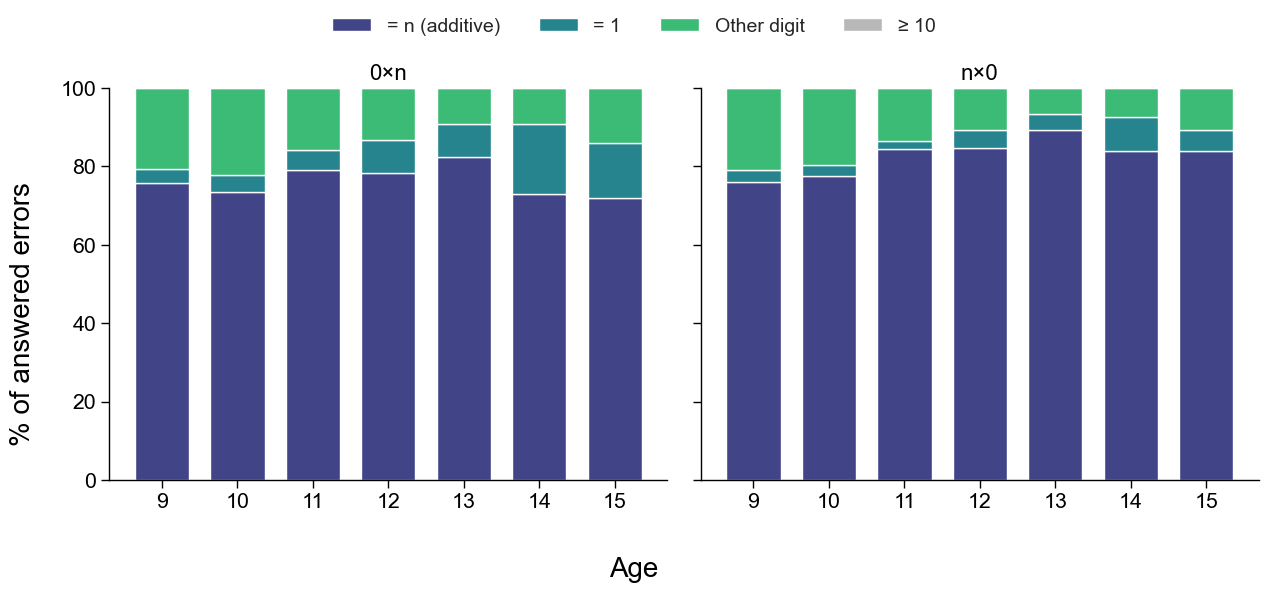

In [27]:
def type_mix(d):
    m = (d[d.is_error & d.answered].pivot_table(index=["direction", "course_age"], columns="error_type",
                                                values="n_responses", aggfunc="sum")
         .reindex(columns=ERROR_TYPES).fillna(0))
    return 100 * m.div(m.sum(axis=1), axis=0)

def type_figure(d, stem):
    mix = type_mix(d)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
    for ax, (direction, title) in zip(axes, [("0xn", "0×n"), ("nx0", "n×0")]):
        m = mix.loc[direction]
        bottom = np.zeros(len(m))
        for col, color in zip(ERROR_TYPES, C_TYPES):
            ax.bar(m.index.astype(str), m[col], bottom=bottom, color=color, label=col, width=0.72)
            bottom += m[col].to_numpy()
        ax.set_title(title, fontsize=FONT_MED, color="black"); ax.set_ylim(0, 100)
        sns.despine(ax=ax)
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, frameon=False, fontsize=FONT_MED - 2, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.07))
    fig.supxlabel("Age", fontsize=FONT_BIG, color="black")
    fig.supylabel("% of answered errors", fontsize=FONT_BIG, color="black")
    fig.tight_layout(); paint_it_black(axes); save(fig, stem)
    return mix

mix = type_figure(zero, "error_types_zero_facts_by_age_ES_2025")
mix.round(1)

## How much of the response is `0×n = n` / `n×0 = n`

`pct_of_all_responses` is the headline number: of every response given to that fact, how many are
the answer `n`. Answering `n` is never correct on a 0-fact, so this is the share of the whole
response volume lost to this single mistake. `pct_of_answered_errors` is the same count over the
answered errors only — what an error looks like, once one is made.

In [28]:
def identity_share(d, by=("direction", "course_age")):
    by = list(by)
    g = d.groupby(by)
    out = pd.DataFrame({
        "responses": g.n_responses.sum(),
        "errors": d[d.is_error].groupby(by).n_responses.sum(),
        "answered_errors": d[d.is_error & d.answered].groupby(by).n_responses.sum(),
        "n_error": d[d.is_error & d.error_type.eq("= n (additive)")].groupby(by).n_responses.sum(),
    }).fillna(0)
    out = out.assign(pct_of_all_responses=(100 * out.n_error / out.responses).round(1),
                     pct_of_answered_errors=(100 * out.n_error / out.answered_errors).round(1))
    return out.astype({"responses": int, "errors": int, "answered_errors": int, "n_error": int})

display(identity_share(zero))
display(identity_share(zero, by=["direction"]))
display(identity_share(zero, by=["operation"]))

responses  errors  answered_errors  n_error  \
direction course_age                                                
0xn       9               17202    3441             3425     2598   
          10              65570    8157             8120     5959   
          11              74101    7009             6980     5523   
          12              34557    2595             2578     2022   
          13              35491    2185             2176     1791   
          14              18341     731              727      530   
          15               5187     135              135       97   
nx0       9               17296    3580             3574     2718   
          10              66203    9070             9030     7000   
          11              74565    9058             9036     7621   
          12              34465    3783             3771     3198   
          13              35470    3191             3183     2846   
          14              18133    1204             1202     1010   
          15               5270     187              187      157   

                      pct_of_all_responses  pct_of_answered_errors  
direction course_age                                                
0xn       9                           15.1                    75.9  
          10                           9.1                    73.4  
          11                           7.5                    79.1  
          12                           5.9                    78.4  
          13                           5.0                    82.3  
          14                           2.9                    72.9  
          15                           1.9                    71.9  
nx0       9                           15.7                    76.0  
          10                          10.6                    77.5  
          11                          10.2                    84.3  
          12                           9.3                    84.8  
          13                           8.0                    89.4  
          14                           5.6                    84.0  
          15                           3.0                    84.0

,responses,errors,answered_errors,n_error,pct_of_all_responses,pct_of_answered_errors
direction,,,,,,
0xn,250449,24253,24141,18520,7.4,76.7
nx0,251402,30073,29983,24550,9.8,81.9


,responses,errors,answered_errors,n_error,pct_of_all_responses,pct_of_answered_errors
operation,,,,,,
0×1,27910,3100,3082,2603,9.3,84.5
0×2,27503,2621,2607,1937,7.0,74.3
0×3,28052,2604,2589,1899,6.8,73.3
0×4,27969,2597,2587,1941,6.9,75.0
0×5,27843,2413,2402,1781,6.4,74.1
0×6,27814,2634,2624,2023,7.3,77.1
0×7,27866,2835,2831,2173,7.8,76.8
0×8,27635,2609,2595,1950,7.1,75.1
0×9,27857,2840,2824,2213,7.9,78.4


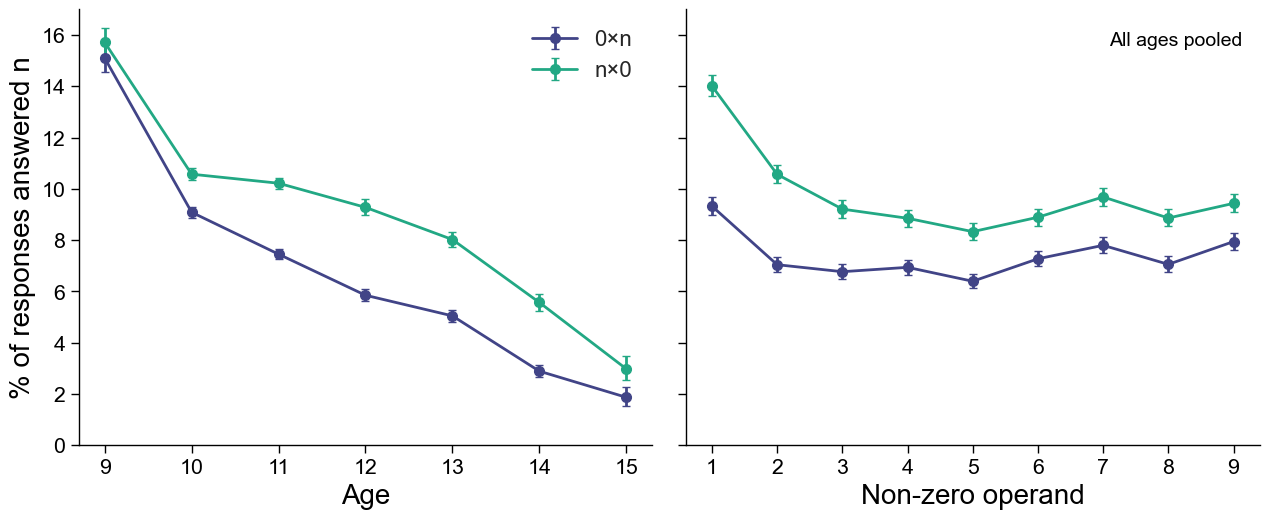

In [29]:
def wilson(k, n, z=1.96):
    p, d = k / n, 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / d
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / d
    return 100 * (centre - half), 100 * (centre + half)

def identity_figure(d, stem):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
    for ax, x_col, xlabel in [(axes[0], "course_age", "Age"), (axes[1], "n", "Non-zero operand")]:
        t = identity_share(d, by=["direction", x_col])
        for direction, label, color in [("0xn", "0×n", C_DIR[0]), ("nx0", "n×0", C_DIR[1])]:
            g = t.loc[direction]
            pct = 100 * g.n_error / g.responses
            lo, hi = wilson(g.n_error.to_numpy(), g.responses.to_numpy())
            ax.errorbar(g.index, pct, yerr=[pct - lo, hi - pct], fmt="o-", capsize=3,
                        markersize=7, linewidth=2, color=color, label=label)
        ax.set_xlabel(xlabel, fontsize=FONT_BIG, color="black")
        ax.set_xticks(sorted(t.index.get_level_values(1).unique()))
        ax.set_ylim(0, None); sns.despine(ax=ax)
    axes[0].set_ylabel("% of responses answered n", fontsize=FONT_BIG, color="black")
    axes[0].legend(frameon=False, fontsize=FONT_MED)
    axes[1].text(0.97, 0.95, "All ages pooled", transform=axes[1].transAxes, ha="right",
                 va="top", fontsize=FONT_MED - 2, color="black")
    fig.tight_layout(); paint_it_black(axes); save(fig, stem)

identity_figure(zero, "identity_error_share_ES_2025")

In [30]:
# sanity checks
assert np.allclose(mix.sum(axis=1), 100)
raw = cached_query(SQL, cache_dir=ROOT / "cache")
assert df.n_responses.sum() <= raw.n_responses.sum()          # only the <30 cells are dropped
check = zero[zero.is_error & zero.error_type.eq("= n (additive)")].n_responses.sum()
assert check == identity_share(zero, by=["direction"]).n_error.sum()
print(f"{len(df):,} rows | {df.n_responses.sum():,} of {raw.n_responses.sum():,} responses kept")
print(f"0-fact errors answered with n: {check:,}")

34,474 rows | 4,680,476 of 4,680,548 responses kept
0-fact errors answered with n: 43,070
